In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
import jno
import jno.numpy as jnn
crux_poseidonT = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/poseidonT_data_32/crux.pkl')
crux_pdeformer = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/pdeformer2_small_data_32/crux.pkl')
crux_fno = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/fno_data_32/crux.pkl')
crux_unet = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/unet_data_32/crux.pkl')
crux_cno = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/cno_data_32/crux.pkl')
crux_pit = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/pit_data_32/crux.pkl')

crux_morphti = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/morphTi_data_32/crux.pkl')
crux_morphS = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/morphS_data_32/crux.pkl')

crux_mppTi = jno.core.load('/home/b8cl/projects/jNO/examples/poseidon/runs/mppTi_data_32/crux.pkl')

tst = jno.domain.load('/home/b8cl/projects/jNO/examples/poseidon/domain_32_inference.pkl')
_u = tst.context["_u"]
_f = tst.context["_f"]
_u = (_u - jnn.mean(tst.context["_u"])) / jnn.std(tst.context["_u"])
_f = (_f - jnn.mean(tst.context["_f"])) / jnn.std(tst.context["_f"])
tst.context["_u"] = _u
tst.context["_f"] = _f

ERROR:2026-02-23 00:18:02,437:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/b8cl/projects/jNO/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/b8cl/projects/jNO/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/b8cl/projects/jNO/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE
2026-02-23 00:18:05,068 - INFO - Device mesh: Mesh('batch': 1, 'model': 1, axis_types=(Auto, Auto)) (shape: (1, 1))
2026-02-2

In [2]:
pred = crux_poseidonT.eval(crux_poseidonT.constraints[0].args[0].right, tst)
print(pred.shape)

(32, 1, 1, 128, 128, 1)


In [3]:
crux_pdeformer_pred = crux_pdeformer.eval(crux_pdeformer.constraints[0].args[0].right, tst)
crux_pdeformer_pred = crux_pdeformer_pred.reshape((32, 1, 1, 128, 128, 1))
print(crux_pdeformer_pred.shape)

(32, 1, 1, 128, 128, 1)


In [4]:
crux_fno_pred = crux_fno.eval(crux_fno.constraints[0].args[0].right, tst)
crux_fno_pred = crux_fno_pred.reshape((32, 1, 1, 128, 128, 1))
print(crux_fno_pred.shape)

(32, 1, 1, 128, 128, 1)


In [5]:
crux_unet_pred = crux_unet.eval(crux_unet.constraints[0].args[0].right, tst)
crux_unet_pred = crux_unet_pred.reshape((32, 1, 1, 128, 128, 1))
print(crux_unet_pred.shape)

(32, 1, 1, 128, 128, 1)


In [6]:
crux_cno_pred = crux_cno.eval(crux_cno.constraints[0].args[0].right, tst)
crux_cno_pred = crux_cno_pred.reshape((32, 1, 1, 128, 128, 1))
print(crux_cno_pred.shape)

(32, 1, 1, 128, 128, 1)


In [7]:
crux_pit_pred = crux_pit.eval(crux_pit.constraints[0].args[0].right, tst)
crux_pit_pred = crux_pit_pred.reshape((32, 1, 1, 128, 128, 1))
print(crux_pit_pred.shape)

(32, 1, 1, 128, 128, 1)


In [8]:
crux_morphti_pred = crux_morphti.eval(crux_morphti.constraints[0].args[0].right, tst)
crux_morphti_pred = crux_morphti_pred.reshape((32, 1, 1, 128, 128, 1))
print(crux_morphti_pred.shape)

(32, 1, 1, 128, 128, 1)


In [9]:
crux_morphS_pred = crux_morphS.eval(crux_morphS.constraints[0].args[0].right, tst)
crux_morphS_pred = crux_morphS_pred.reshape((32, 1, 1, 128, 128, 1))
print(crux_morphS_pred.shape)

(32, 1, 1, 128, 128, 1)


In [10]:
crux_mppTi_pred = crux_mppTi.eval(crux_mppTi.constraints[0].args[0].right, tst)
crux_mppTi_pred = crux_mppTi_pred.reshape((32, 1, 1, 128, 128, 1))
print(crux_mppTi_pred.shape)

(32, 1, 1, 128, 128, 1)


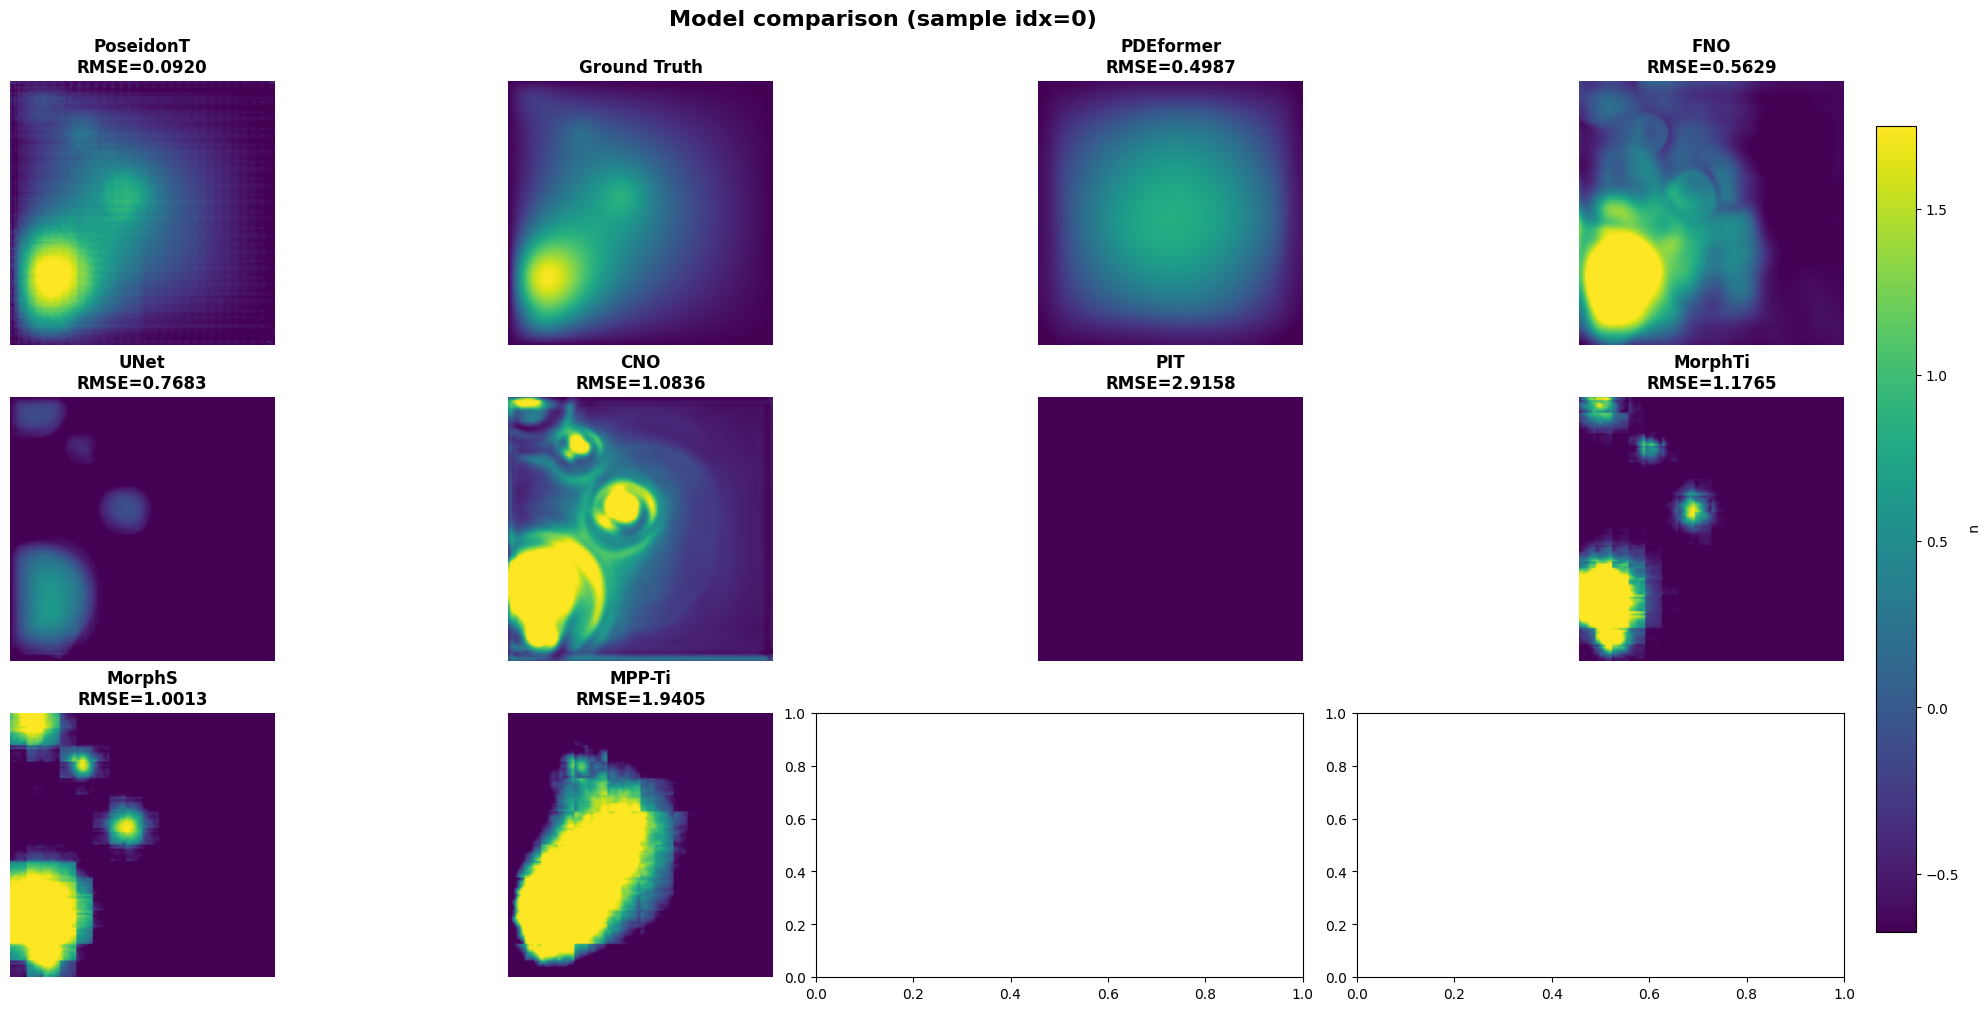

In [12]:
import matplotlib.pyplot as plt

idx = 0
gt = tst.context["_u"][idx, 0, 0, ..., 0]

panels = [
    ("PoseidonT", pred[idx, 0, 0, ..., 0]),
    ("Ground Truth", gt),
    ("PDEformer", crux_pdeformer_pred[idx, 0, 0, ..., 0]),
    ("FNO", crux_fno_pred[idx, 0, 0, ..., 0]),
    ("UNet", crux_unet_pred[idx, 0, 0, ..., 0]),
    ("CNO", crux_cno_pred[idx, 0, 0, ..., 0]),
    ("PIT", crux_pit_pred[idx, 0, 0, ..., 0]),
    ("MorphTi", crux_morphti_pred[idx, 0, 0, ..., 0]),
    ("MorphS", crux_morphS_pred[idx, 0, 0, ..., 0]),
    ("MPP-Ti", crux_mppTi_pred[idx, 0, 0, ..., 0]),
]

vmin = gt.min() #min(float(img.min()) for _, img in panels)
vmax = gt.max() #max(float(img.max()) for _, img in panels)

fig, ax = plt.subplots(3, 4, figsize=(22, 10), constrained_layout=True)
ax = ax.ravel()

for i, (title, img) in enumerate(panels):
    im = ax[i].imshow(img, cmap="viridis", vmin=vmin, vmax=vmax)
    if title != "Ground Truth":
        rmse = float((((img - gt) ** 2).mean()) ** 0.5)
        ax[i].set_title(f"{title}\nRMSE={rmse:.4f}", fontsize=12, fontweight="bold")
    else:
        ax[i].set_title(title, fontsize=12, fontweight="bold")
    ax[i].axis("off")

cbar = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.01)
cbar.set_label("u", rotation=270, labelpad=14)

fig.suptitle(f"Model comparison (sample idx={idx})", fontsize=16, fontweight="bold")
plt.show()


In [ ]:
import numpy as np

# Check the expression tree structure
expr = crux_poseidonT.constraints[0]  # the .mse node
print("Full constraint tree:")
print(repr(expr))
print()

# The prediction node
pred_node = crux_poseidonT.constraints[0].args[0].right  # u(*input)
print("Prediction node:", repr(pred_node))
print()

# Check what's in the test domain vs what the model expects
print("Test domain context:")
for k, v in tst.context.items():
    arr = np.asarray(v)
    print(f"  {k}: shape={arr.shape}, min={arr.min():.6f}, max={arr.max():.6f}, mean={arr.mean():.6f}")

print()
print("Prediction stats:")
p = np.asarray(pred)
print(f"  pred: shape={p.shape}, min={p.min():.6f}, max={p.max():.6f}, mean={p.mean():.6f}")

gt = np.asarray(tst.context["_u"])
print(f"  _u:   shape={gt.shape}, min={gt.min():.6f}, max={gt.max():.6f}, mean={gt.mean():.6f}")
print()

# Per-sample MSE (same metric as training)
mse_per_sample = np.mean((p - gt)**2, axis=(1,2,3,4,5))
print(f"Per-sample MSE: min={mse_per_sample.min():.2e}, max={mse_per_sample.max():.2e}, mean={mse_per_sample.mean():.2e}")
print(f"Per-sample RMSE: {np.sqrt(mse_per_sample.mean()):.6f}")
print(f"Relative L2: {np.sqrt(np.mean((p-gt)**2)) / np.sqrt(np.mean(gt**2)):.4f}")